**Sentiment Analysis on Movie Reviews**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading the Dataset

In [2]:
import pandas as pd
import numpy as np

raw_reviews_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CS-171/IMDB Dataset.csv")
raw_reviews_df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Exploratory Data Analysis

  sentiment  count
0  positive  25000
1  negative  25000


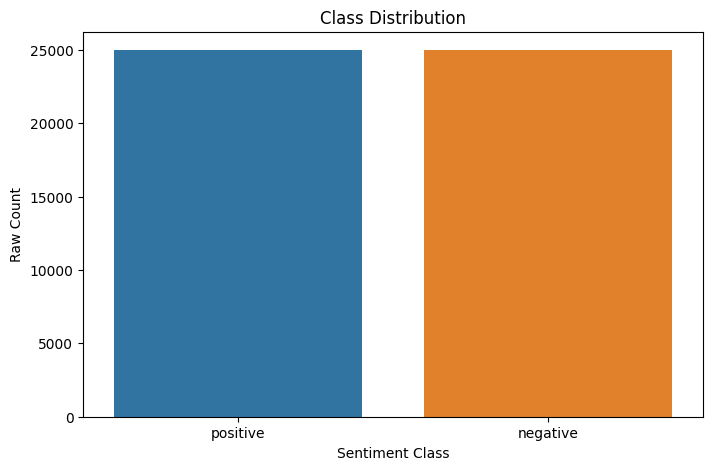

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class Distributions
class_distributions = raw_reviews_df['sentiment'].value_counts().reset_index()
print(class_distributions)

plt.figure(figsize=(8, 5))
sns.barplot(data=class_distributions,
            x='sentiment',
            y='count',
            hue='sentiment')

plt.title("Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Raw Count")
plt.show()

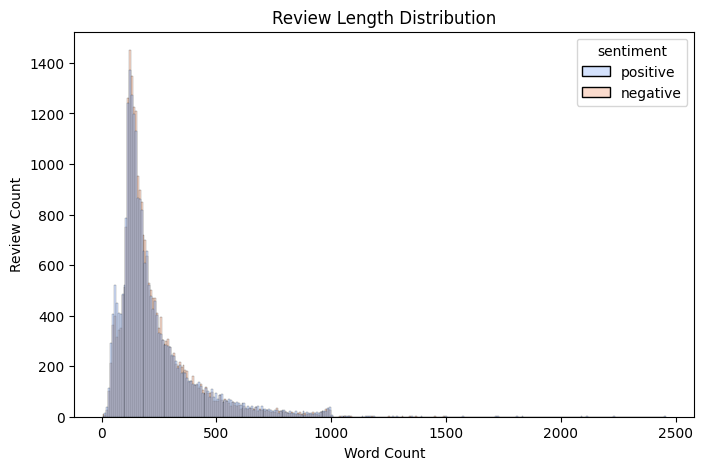

In [17]:
# Sequence Length

# The replace function was added to deal with the line break tags seen in the data preview above
raw_reviews_df['sequence_word_length'] = raw_reviews_df['review'].str.replace('<br />', ' ', regex=False).str.split().str.len()

plt.figure(figsize=(8, 5))
sns.histplot(raw_reviews_df,
             x = 'sequence_word_length',
             hue = 'sentiment',
             palette = 'coolwarm')

plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Review Count")
plt.show()

Data Preprocessing

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Basic Cleaning (removing <br /> tags again)
raw_reviews_df['cleaned_review'] = raw_reviews_df['review'].str.replace('<br />', ' ', regex=False)

# Split into Train and Test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    raw_reviews_df['cleaned_review'],
    raw_reviews_df['sentiment'].map({'positive': 1, 'negative': 0}),
    test_size=0.2,
    random_state=42
)

# Keras Tokenization
unique_words_count = len(set(raw_reviews_df['cleaned_review'].str.lower().str.split().explode()))
print(f"Total unique words in dataset: {unique_words_count}")

VOCAB_SIZE = 10000 # How many of the most frequent unique words we keep (TO DO: try other values for this)

percentile_90 = sequence_word_length.quantile(0.90) # We want to preseverve most our data, so our max_len is based on percentile
print(f"The 90th percentile of review lengths is: {percentile_90} words.")

MAX_LEN = int(percentile_90) # Max token length of each review

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

# Transform and Pad
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_LEN, padding='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=MAX_LEN, padding='post')

BATCH_SIZE = 64
# Batching
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_dataset = train_dataset.shuffle(buffer_size=10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Datasets created with batch size: {BATCH_SIZE}")

Total unique words in dataset: 365437
The 90th percentile of review lengths is: 447.0 words.
Datasets created with batch size: 64


Pre-Trained Model Eval

In [6]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0  # Uncomment and set to 0 if you have a GPU and want to use it, otherwise keep it commented for CPU
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [9]:
from tqdm.notebook import tqdm

# Run inference on the X_test_raw set
# We will manually batch the data to guarantee the tqdm progress bar updates in real-time
results = []
batch_size = 32

for i in tqdm(range(0, len(X_test_raw), batch_size)):
    # Extract a batch of texts
    batch_texts = X_test_raw.iloc[i:i+batch_size].tolist()
    # Run the pipeline on this batch
    batch_results = classifier(batch_texts, truncation=True)
    results.extend(batch_results)

# Quick check
print(f"\nReview: {X_test_raw.iloc[0][:100]}...")
print(f"Sentiment: {results[0]['label']} (Score: {results[0]['score']:.4f})")


  0%|          | 0/313 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Review: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall ...
Sentiment: NEGATIVE (Score: 0.9849)


Pre-Trained Model Evaluation


Accuracy:  0.8883
Precision: 0.9144
Recall:    0.8587
F1-Score:  0.8857

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.92      0.89      4961
    Positive       0.91      0.86      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



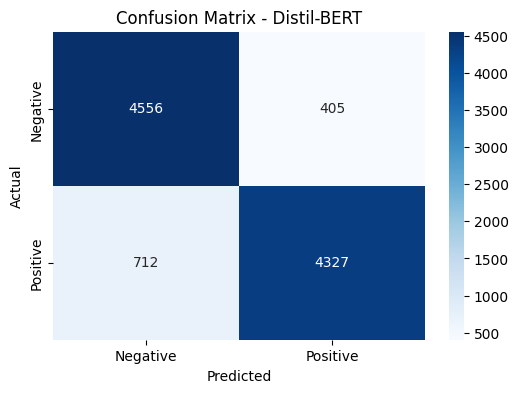

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Map the string labels from the pipeline to binary integers
y_pred = [1 if res['label'] == 'POSITIVE' else 0 for res in results]

# Compute evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Distil-BERT')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
